- Chuyển đổi các cột chứa số nhưng dạng text và các cột int về kiểu float64
- Kiểm tra xem các cột nào bị missing values và thống kê tỉ lệ missing, số lượng missing rồi vẽ biểu đồ trực quan tỉ lệ missing của các cột
- Thống kê các giá trị min, max, mean, median, độ lệch chuẩn, phương sai, phân vị thứ nhất, phân vị thứ ba của từng cột trước khi xử lí missing values

File được tìm thấy tại: data.csv
Đã đọc thành công file với 19811 dòng và 29 cột

Đã lưu file đã xử lý tại: data_processed.csv

PHÂN TÍCH MISSING VALUES TRÊN DỮ LIỆU ĐÃ XỬ LÝ

BẢNG THỐNG KÊ MISSING VALUES
           Thuộc tính Kiểu dữ liệu  Số lượng missing  Tỉ lệ missing (%)
                price      float64                 0               0.00
       original_price      float64                 0               0.00
        discount_rate      float64                 0               0.00
        quantity_sold      float64              5639              28.46
       rating_average      float64                 0               0.00
         review_count      float64                 0               0.00
     is_return_policy      float64                 0               0.00
     is_freeship_xtra      float64                63               0.32
         is_authentic      float64                63               0.32
          image_count      float64                 0               0.00
   

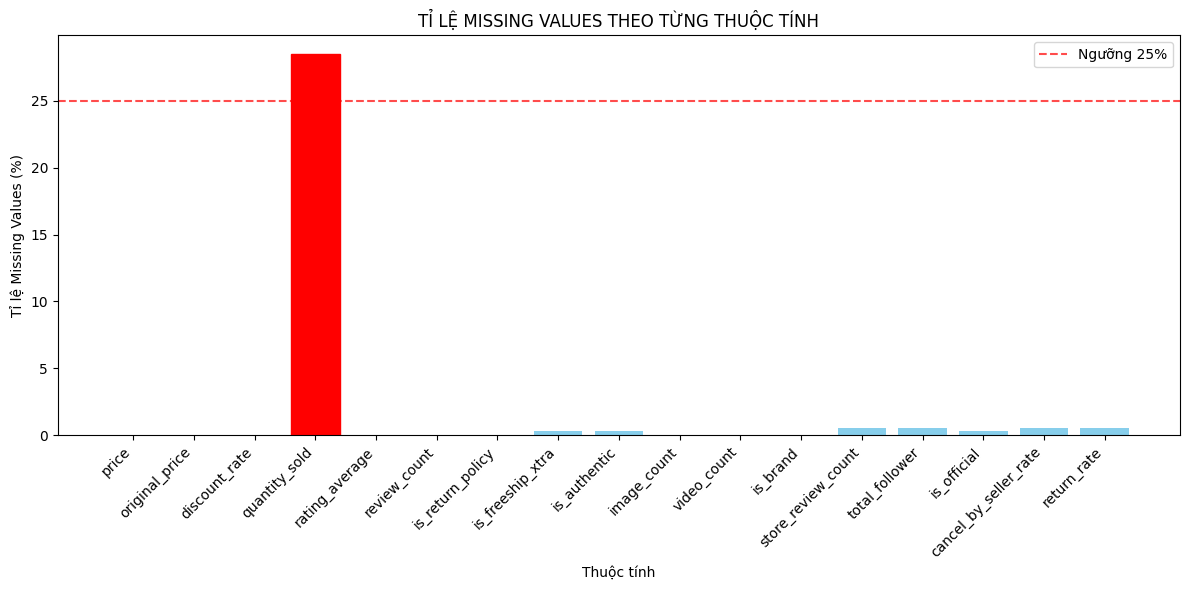


THÔNG TIN CHI TIẾT VỀ PHÂN BỐ CỦA TẤT CẢ CÁC CỘT:

price:
  - Kiểu dữ liệu: float64
  - Số giá trị unique: 4003
  - Giá trị min: 1000.000000
  - Giá trị max: 1303175000.000000
  - Giá trị trung bình: 2141107.902529
  - Giá trị trung vị: 230000.000000
  - Độ lệch chuẩn: 17957358.496893
  - Phương sai: 322466724185922.125000
  - Phân vị 25%: 102000.000000
  - Phân vị 75%: 591500.000000
  - Không có missing values

original_price:
  - Kiểu dữ liệu: float64
  - Số giá trị unique: 3248
  - Giá trị min: 1000.000000
  - Giá trị max: 1303175000.000000
  - Giá trị trung bình: 2286529.781384
  - Giá trị trung vị: 259000.000000
  - Độ lệch chuẩn: 18112216.974927
  - Phương sai: 328052403746825.437500
  - Phân vị 25%: 118000.000000
  - Phân vị 75%: 660000.000000
  - Không có missing values

discount_rate:
  - Kiểu dữ liệu: float64
  - Số giá trị unique: 79
  - Giá trị min: 0.000000
  - Giá trị max: 83.000000
  - Giá trị trung bình: 9.086921
  - Giá trị trung vị: 0.000000
  - Độ lệch chuẩn: 14.108

In [ ]:
#!pip install matplotlib
import pandas as pd
import numpy as np
import os

file_path = 'data.csv' 

# Kiểm tra xem file có tồn tại không
if not os.path.exists(file_path):
    # Tìm kiếm file trong toàn bộ thư mục hiện tại
    import glob
    search_results = glob.glob('**/data.csv', recursive=True)

    if search_results:
        file_path = search_results[0]
        print(f"Tìm thấy file tại: {file_path}")
    else:
        print("Không tìm thấy file data.csv trong thư mục hiện tại. Vui lòng kiểm tra đường dẫn.")
        # Tạo danh sách các file CSV có sẵn
        csv_files = glob.glob('**/*.csv', recursive=True)
        if csv_files:
            print("\nCác file CSV có sẵn trong thư mục hiện tại:")
            for i, file in enumerate(csv_files[:10], 1):
                print(f"{i}. {file}")
else:
    print(f"File được tìm thấy tại: {file_path}")

# Đọc dữ liệu
try:
    df = pd.read_csv(file_path)
    print(f"Đã đọc thành công file với {len(df)} dòng và {len(df.columns)} cột")
except Exception as e:
    print(f"Lỗi khi đọc file: {e}")
    # Thử đọc với encoding khác nếu cần
    try:
        df = pd.read_csv(file_path, encoding='utf-8')
    except:
        try:
            df = pd.read_csv(file_path, encoding='latin-1')
        except:
            print("Không thể đọc file với các encoding thông thường.")

# Xử lý chuyển đổi dữ liệu phần trăm

# Tạo bản sao để xử lý
df_processed = df.copy()

# Xử lý cột 'cancel_by_seller_rate' và 'return_rate'
percent_columns = ['cancel_by_seller_rate', 'return_rate']

for col in percent_columns:
    if col in df_processed.columns:
        # Đếm số lượng giá trị không phải NaN
        non_null_count = df_processed[col].notna().sum()

        if non_null_count > 0:

            # Kiểm tra xem có chứa ký tự '%' không
            has_percent = df_processed[col].astype(str).str.contains('%').any()

            # Xử lý chuyển đổi
            if has_percent:
                # Loại bỏ ký tự '%' và chuyển đổi sang số
                df_processed[col] = df_processed[col].astype(str).str.replace('%', '', regex=False)

                # Loại bỏ khoảng trắng
                df_processed[col] = df_processed[col].str.strip()

                # Chuyển đổi sang số, không hợp lệ sẽ thành NaN
                df_processed[col] = pd.to_numeric(df_processed[col], errors='coerce')

                # Chia cho 100 để chuyển từ phần trăm sang số thập phân
                df_processed[col] = df_processed[col] / 100
            else:
                # Nếu không có '%', thử chuyển trực tiếp sang số
                df_processed[col] = pd.to_numeric(df_processed[col], errors='coerce')
    else:
        print(f"\nCột '{col}' không tồn tại trong dataset")

# Danh sách các cột số cần kiểm tra
numeric_columns_to_check = [
    'price', 'original_price', 'discount_rate', 'quantity_sold',
    'rating_average', 'review_count', 'is_return_policy',
    'is_freeship_xtra', 'is_authentic', 'image_count', 'video_count',
    'is_brand', 'store_review_count', 'total_follower', 'is_official'
]

for col in numeric_columns_to_check:
    if col in df_processed.columns:
        if df_processed[col].dtype == 'object':
            print(f"\nCột '{col}' có kiểu object, đang chuyển sang numeric...")

            # Đếm số giá trị không phải NaN trước khi chuyển
            before_count = df_processed[col].notna().sum()

            # Chuyển đổi sang numeric
            df_processed[col] = pd.to_numeric(df_processed[col], errors='coerce')

            # Đếm số giá trị không phải NaN sau khi chuyển
            after_count = df_processed[col].notna().sum()

            lost_values = before_count - after_count
            if lost_values > 0:
                print(f"  - Mất {lost_values} giá trị không thể chuyển đổi")

            print(f"  - Kiểu dữ liệu sau: {df_processed[col].dtype}")

# Lưu file CSV mới
output_file_path = 'data_processed.csv'
df_processed.to_csv(output_file_path, index=False)
print(f"\nĐã lưu file đã xử lý tại: {output_file_path}")

# Phân tích missing values trên dữ liệu đã xử lý
print("\n" + "="*60)
print("PHÂN TÍCH MISSING VALUES TRÊN DỮ LIỆU ĐÃ XỬ LÝ")
print("="*60)

# Sử dụng dataframe đã xử lý
df = df_processed

# Danh sách các cột cần kiểm tra
columns_to_check = [
    'price', 'original_price', 'discount_rate', 'quantity_sold',
    'rating_average', 'review_count', 'is_return_policy',
    'is_freeship_xtra', 'is_authentic', 'image_count', 'video_count',
    'is_brand', 'store_review_count', 'total_follower', 'is_official',
    'cancel_by_seller_rate', 'return_rate'
]

# Kiểm tra xem các cột có tồn tại trong dataframe không
existing_columns = [col for col in columns_to_check if col in df.columns]
missing_columns = [col for col in columns_to_check if col not in df.columns]

if missing_columns:
    print(f"Các cột không tồn tại trong dataset: {missing_columns}")
    print(f"Tiếp tục với {len(existing_columns)} cột có sẵn...")

# Tạo bảng thống kê missing values
missing_stats = []
total_rows = len(df)

for col in existing_columns:
    # Đếm missing values (NaN)
    missing_count = df[col].isnull().sum()
    missing_percentage = (missing_count / total_rows) * 100

    missing_stats.append({
        'Thuộc tính': col,
        'Kiểu dữ liệu': df[col].dtype,
        'Số lượng missing': missing_count,
        'Tỉ lệ missing (%)': round(missing_percentage, 2)
    })

# Tạo DataFrame từ bảng thống kê
missing_df = pd.DataFrame(missing_stats)

# In bảng thống kê
print("\nBẢNG THỐNG KÊ MISSING VALUES")
print("="*80)
print(missing_df.to_string(index=False))
print("="*80)

# Tính toán chỉ số tổng hợp
columns_with_missing = missing_df[missing_df['Số lượng missing'] > 0]
num_columns_with_missing = len(columns_with_missing)

# Tính tỉ lệ missing trung bình (chỉ tính các cột có missing)
avg_missing_rate = columns_with_missing['Tỉ lệ missing (%)'].mean() if num_columns_with_missing > 0 else 0

# Phân loại cột theo mức độ missing (ngưỡng 25%)
high_missing_cols = missing_df[missing_df['Tỉ lệ missing (%)'] > 25]['Thuộc tính'].tolist()
low_missing_cols = missing_df[(missing_df['Tỉ lệ missing (%)'] > 0) &
                              (missing_df['Tỉ lệ missing (%)'] <= 25)]['Thuộc tính'].tolist()
no_missing_cols = missing_df[missing_df['Tỉ lệ missing (%)'] == 0]['Thuộc tính'].tolist()

# In báo cáo tổng hợp
print("\nBÁO CÁO TỔNG HỢP")
print("="*60)
print(f"Tổng số dòng dữ liệu: {total_rows}")
print(f"Số cột được kiểm tra: {len(existing_columns)}")
print(f"Số cột có missing values: {num_columns_with_missing}")
print(f"Tỉ lệ missing values trung bình: {avg_missing_rate:.2f}%")

print(f"\nCÁC CỘT CÓ MISSING VALUES NHIỀU (>25%): {len(high_missing_cols)} cột")
if high_missing_cols:
    for col in high_missing_cols:
        rate = missing_df[missing_df['Thuộc tính'] == col]['Tỉ lệ missing (%)'].values[0]
        dtype = missing_df[missing_df['Thuộc tính'] == col]['Kiểu dữ liệu'].values[0]
        print(f"  - {col} ({dtype}): {rate}%")
else:
    print("  Không có cột nào")

print(f"\nCÁC CỘT CÓ MISSING VALUES ÍT (≤25%): {len(low_missing_cols)} cột")
if low_missing_cols:
    for col in low_missing_cols:
        rate = missing_df[missing_df['Thuộc tính'] == col]['Tỉ lệ missing (%)'].values[0]
        dtype = missing_df[missing_df['Thuộc tính'] == col]['Kiểu dữ liệu'].values[0]
        print(f"  - {col} ({dtype}): {rate}%")
else:
    print("  Không có cột nào")

print(f"\nCÁC CỘT KHÔNG CÓ MISSING VALUES: {len(no_missing_cols)} cột")
if no_missing_cols:
    print(f"  {', '.join(no_missing_cols[:5])}", end="")
    if len(no_missing_cols) > 5:
        print(f" và {len(no_missing_cols) - 5} cột khác")
    else:
        print()

print("="*60)

# Trực quan hóa kết quả
import matplotlib.pyplot as plt

# Tạo biểu đồ tỉ lệ missing values
plt.figure(figsize=(12, 6))
bars = plt.bar(missing_df['Thuộc tính'], missing_df['Tỉ lệ missing (%)'], color='skyblue')
plt.axhline(y=25, color='r', linestyle='--', alpha=0.7, label='Ngưỡng 25%')
plt.xlabel('Thuộc tính')
plt.ylabel('Tỉ lệ Missing Values (%)')
plt.title('TỈ LỆ MISSING VALUES THEO TỪNG THUỘC TÍNH')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()

# Tô màu đỏ cho các cột có missing > 25%
for i, (bar, rate) in enumerate(zip(bars, missing_df['Tỉ lệ missing (%)'])):
    if rate > 25:
        bar.set_color('red')

plt.show()

# Hiển thị thông tin chi tiết về phân bố của TẤT CẢ các cột
print("\nTHÔNG TIN CHI TIẾT VỀ PHÂN BỐ CỦA TẤT CẢ CÁC CỘT:")
print("="*80)

for col in existing_columns:
    print(f"\n{col}:")
    print(f"  - Kiểu dữ liệu: {df[col].dtype}")
    print(f"  - Số giá trị unique: {df[col].nunique()}")

    # Kiểm tra xem cột có phải là numeric không
    is_numeric = pd.api.types.is_numeric_dtype(df[col])

    if is_numeric:
        # Loại bỏ NaN để tính toán thống kê
        numeric_data = df[col].dropna()

        if len(numeric_data) > 0:
            print(f"  - Giá trị min: {numeric_data.min():.6f}")
            print(f"  - Giá trị max: {numeric_data.max():.6f}")
            print(f"  - Giá trị trung bình: {numeric_data.mean():.6f}")
            print(f"  - Giá trị trung vị: {numeric_data.median():.6f}")
            print(f"  - Độ lệch chuẩn: {numeric_data.std():.6f}")
            print(f"  - Phương sai: {numeric_data.var():.6f}")

            # Phân vị
            print(f"  - Phân vị 25%: {numeric_data.quantile(0.25):.6f}")
            print(f"  - Phân vị 75%: {numeric_data.quantile(0.75):.6f}")
        else:
            print("  - Không có giá trị số hợp lệ để tính toán thống kê")
    else:
        print("  - Đây không phải là cột số, không áp dụng các thống kê số")

    # Thông tin missing values cho cột này
    missing_count = df[col].isnull().sum()
    if missing_count > 0:
        missing_percentage = (missing_count / total_rows) * 100
        print(f"  - Số lượng missing values: {missing_count}")
        print(f"  - Tỉ lệ missing values: {missing_percentage:.2f}%")
    else:
        print("  - Không có missing values")

print("="*80)






- quantity_sold: Điền 0.0 cho 5639 giá trị missing
- Tất cả cột is_ (biến nhị phân): Điền 0.0 nếu có missing
- KNN Imputer: Có 11 cột được chọn cho KNN, trong đó:
+ 7 cột không có missing (dùng làm đặc trưng hỗ trợ)
+ 4 cột có missing cần điền
+ Dùng thuật toán K-Nearest Neighbors với n_neighbors=5
+ Tìm 5 hàng xóm gần nhất dựa trên các cột không missing
+ Tính giá trị điền từ giá trị trung bình của 5 hàng đó

4 cột được điền: store_review_count, total_follower, cancel_by_seller_rate, return_rate

IMPUTATION MISSING VALUES VỚI KNN
Đã đọc file: data_processed.csv
Kích thước dữ liệu: 19811 dòng, 29 cột

KIỂM TRA MISSING VALUES TRƯỚC KHI IMPUTE
quantity_sold: 5639 missing (28.46%)
is_freeship_xtra: 63 missing (0.32%)
is_authentic: 63 missing (0.32%)
store_review_count: 114 missing (0.58%)
total_follower: 114 missing (0.58%)
is_official: 63 missing (0.32%)
cancel_by_seller_rate: 114 missing (0.58%)
return_rate: 114 missing (0.58%)
Đã điền 0.0 cho quantity_sold: 5639 giá trị
Các cột sẽ dùng KNN Imputer (11 cột):
  1. price: 0 missing
  2. original_price: 0 missing
  3. discount_rate: 0 missing
  4. rating_average: 0 missing
  5. review_count: 0 missing
  6. image_count: 0 missing
  7. video_count: 0 missing
  8. store_review_count: 114 missing
  9. total_follower: 114 missing
  10. cancel_by_seller_rate: 114 missing
  11. return_rate: 114 missing

Còn 4 cột có missing values cần xử lý bằng KNN

Thông tin imputation cho từng cột:
  store_review_count: 114 → 0 missing
  total_follower:

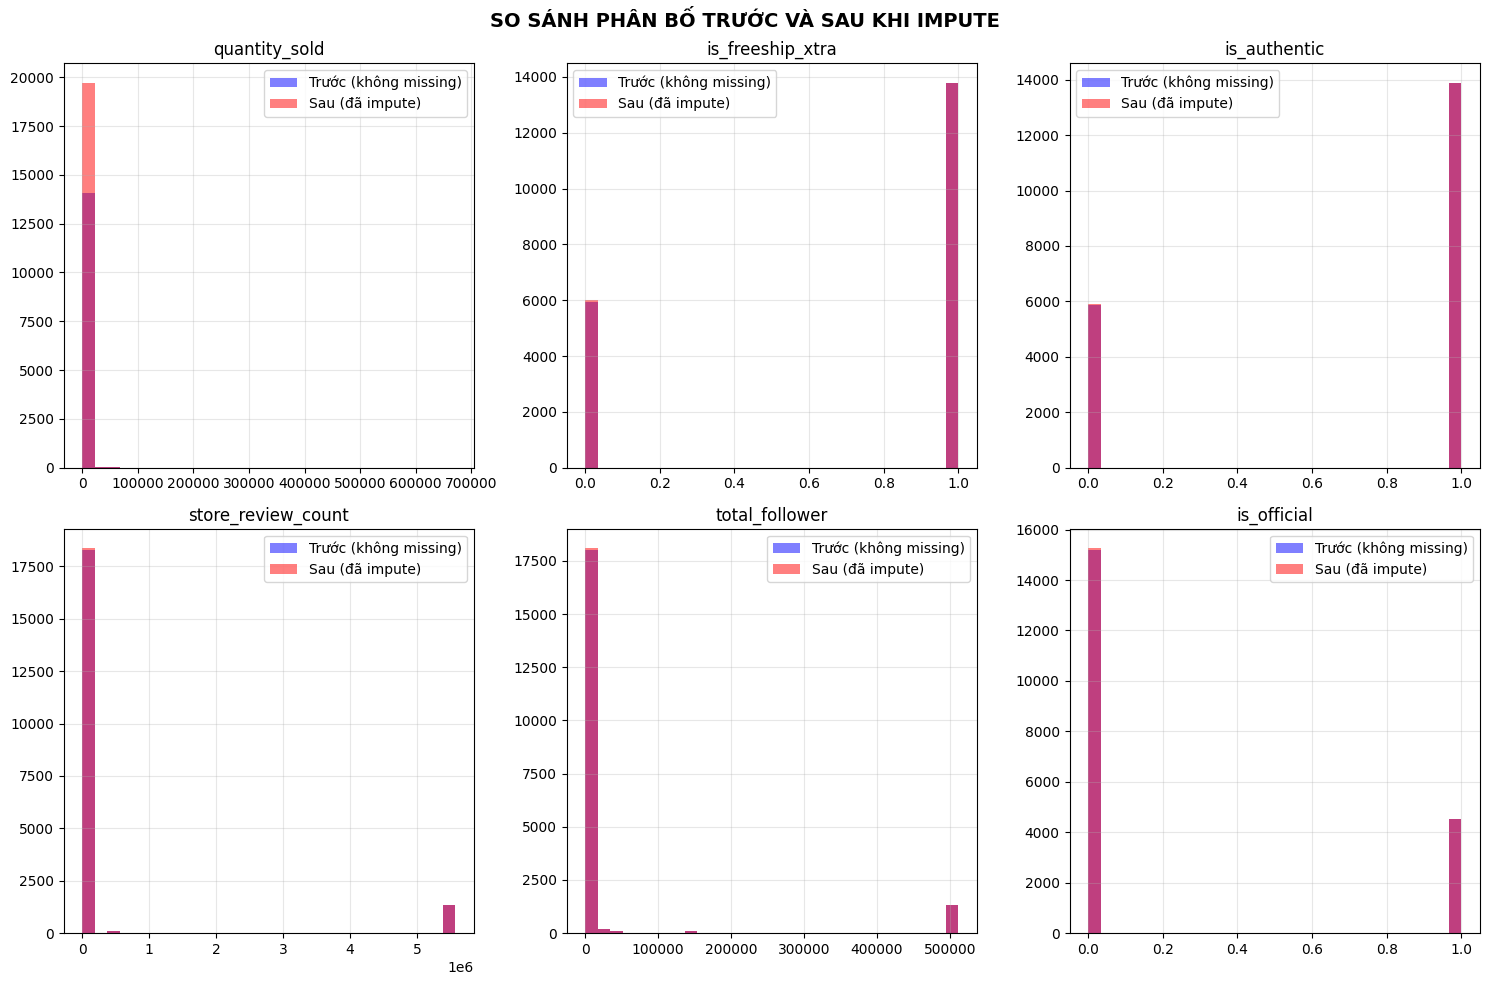

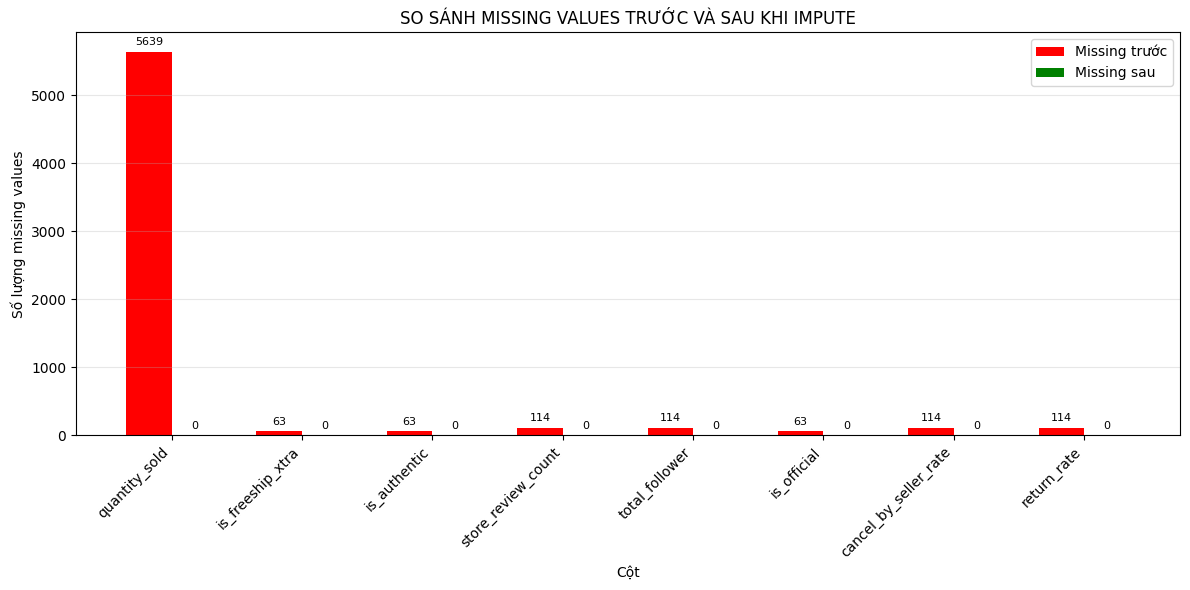


 THỐNG KÊ IMPUTATION:
  • Tổng số cột được xử lý: 17
  • Số cột điền 0.0: 6
  • Số cột dùng KNN Imputer: 11
  • Tổng missing ban đầu: 6284
  • Tổng missing sau xử lý: 0
  • Tỷ lệ xử lý thành công: 100.0%


In [14]:
#!pip install pandas numpy scikit-learn matplotlib
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
import os
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("IMPUTATION MISSING VALUES VỚI KNN")
print("="*60)

# Đọc file đã preprocess
input_file_path = 'data_processed.csv'  

if not os.path.exists(input_file_path):
    print(f"Không tìm thấy file: {input_file_path}")
    print("Vui lòng đảm bảo file đã được tạo từ bước trước.")
    exit()

# Đọc dữ liệu
try:
    df = pd.read_csv(input_file_path)
    print(f"Đã đọc file: {input_file_path}")
    print(f"Kích thước dữ liệu: {df.shape[0]} dòng, {df.shape[1]} cột")
except Exception as e:
    print(f"Lỗi khi đọc file: {e}")
    exit()

# Danh sách các cột cần xử lý
columns_to_check = [
    'price', 'original_price', 'discount_rate', 'quantity_sold',
    'rating_average', 'review_count', 'is_return_policy',
    'is_freeship_xtra', 'is_authentic', 'image_count', 'video_count',
    'is_brand', 'store_review_count', 'total_follower', 'is_official',
    'cancel_by_seller_rate', 'return_rate'
]

# Chỉ lấy các cột có trong dataframe
existing_columns = [col for col in columns_to_check if col in df.columns]
missing_columns = [col for col in columns_to_check if col not in df.columns]

if missing_columns:
    print(f"Các cột không tồn tại trong dataset: {missing_columns}")
    print(f"Tiếp tục với {len(existing_columns)} cột có sẵn...")

# Kiểm tra missing values trước khi impute
print("\n" + "="*60)
print("KIỂM TRA MISSING VALUES TRƯỚC KHI IMPUTE")
print("="*60)

missing_before = {}
total_rows = len(df)

for col in existing_columns:
    missing_count = df[col].isnull().sum()
    if missing_count > 0:
        missing_percentage = (missing_count / total_rows) * 100
        missing_before[col] = {
            'missing_count': missing_count,
            'missing_percentage': missing_percentage
        }
        print(f"{col}: {missing_count} missing ({missing_percentage:.2f}%)")

if not missing_before:
    print("Không có missing values cần xử lý!")
    exit()

# Tạo bản sao để xử lý
df_imputed = df.copy()

# BƯỚC 1: ĐIỀN 0.0 CHO CÁC CỘT ĐẶC BIỆT

# Xác định các cột cần điền 0.0
zero_impute_cols = []

# 1. quantity_sold
if 'quantity_sold' in existing_columns:
    zero_impute_cols.append('quantity_sold')
    missing_count = df_imputed['quantity_sold'].isnull().sum()
    if missing_count > 0:
        df_imputed['quantity_sold'] = df_imputed['quantity_sold'].fillna(0.0)
        print(f"Đã điền 0.0 cho quantity_sold: {missing_count} giá trị")

# 2. Các cột bắt đầu bằng 'is_'
is_cols = [col for col in existing_columns if col.startswith('is_')]
for col in is_cols:
    zero_impute_cols.append(col)
    missing_count = df_imputed[col].isnull().sum()
    if missing_count > 0:
        df_imputed[col] = df_imputed[col].fillna(0.0)

# BƯỚC 2: CHUẨN BỊ DỮ LIỆU CHO KNN IMPUTER

# Xác định các cột còn lại cần dùng KNN (các cột số không phải là cột đặc biệt)
remaining_numeric_cols = []
for col in existing_columns:
    if col not in zero_impute_cols and pd.api.types.is_numeric_dtype(df_imputed[col]):
        remaining_numeric_cols.append(col)

print(f"Các cột sẽ dùng KNN Imputer ({len(remaining_numeric_cols)} cột):")
for i, col in enumerate(remaining_numeric_cols, 1):
    missing_count = df_imputed[col].isnull().sum()
    print(f"  {i}. {col}: {missing_count} missing")

# Kiểm tra xem còn missing values không
missing_after_zero = {}
for col in remaining_numeric_cols:
    missing_count = df_imputed[col].isnull().sum()
    if missing_count > 0:
        missing_after_zero[col] = missing_count

if not missing_after_zero:
    print("\nKhông còn missing values để xử lý bằng KNN!")
else:
    print(f"\nCòn {len(missing_after_zero)} cột có missing values cần xử lý bằng KNN")

# BƯỚC 3: ÁP DỤNG KNN IMPUTER


if missing_after_zero:
    # Tạo subset dữ liệu chỉ chứa các cột cần impute
    knn_data = df_imputed[remaining_numeric_cols].copy()
    
    # Kiểm tra xem có đủ dữ liệu để thực hiện KNN không
    min_non_missing = knn_data.notna().sum().min()
    if min_non_missing < 2:
        print("Cảnh báo: Một số cột có quá ít dữ liệu không bị missing (<2 giá trị)")
        print("KNN có thể không hoạt động hiệu quả.")
    
    # Áp dụng KNN Imputer

    
    # Tùy chọn 1: KNN với tham số mặc định
    knn_imputer = KNNImputer(n_neighbors=5, weights='uniform')
    
    # Tùy chọn 2: KNN với distance weights (ưu tiên các điểm gần hơn)
    # knn_imputer = KNNImputer(n_neighbors=3, weights='distance')
    
    # Thực hiện imputation
    knn_imputed_array = knn_imputer.fit_transform(knn_data)
    
    # Cập nhật dữ liệu đã impute vào dataframe
    knn_imputed_df = pd.DataFrame(knn_imputed_array, 
                                  columns=remaining_numeric_cols, 
                                  index=df_imputed.index)
    
    # Cập nhật các cột đã impute
    for col in remaining_numeric_cols:
        df_imputed[col] = knn_imputed_df[col]
    
    
    # Hiển thị thông tin về việc impute
    print("\nThông tin imputation cho từng cột:")
    for col in remaining_numeric_cols:
        original_missing = df[col].isnull().sum() if col in df.columns else 0
        final_missing = df_imputed[col].isnull().sum()
        if original_missing > 0:
            print(f"  {col}: {original_missing} → {final_missing} missing")

# BƯỚC 4: KIỂM TRA KẾT QUẢ


# Kiểm tra missing values sau khi impute
missing_after = {}
for col in existing_columns:
    missing_count = df_imputed[col].isnull().sum()
    if missing_count > 0:
        missing_after[col] = missing_count

print("\nTổng hợp kết quả:")
print("-"*40)

# Tạo bảng so sánh
results = []
for col in existing_columns:
    before = df[col].isnull().sum() if col in df.columns else 0
    after = df_imputed[col].isnull().sum()
    
    results.append({
        'Cột': col,
        'Missing trước': before,
        'Missing sau': after,
        'Đã xử lý': '✓' if before > 0 and after == 0 else '✗' if before > 0 else 'N/A'
    })

# Hiển thị bảng kết quả
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# Thống kê tổng quát
total_missing_before = sum([r['Missing trước'] for r in results])
total_missing_after = sum([r['Missing sau'] for r in results])

print(f"\nTỔNG KẾT:")
print(f"• Tổng missing values trước: {total_missing_before}")
print(f"• Tổng missing values sau: {total_missing_after}")
print(f"• Số missing values đã xử lý: {total_missing_before - total_missing_after}")

if total_missing_after == 0:
    print(" TẤT CẢ MISSING VALUES ĐÃ ĐƯỢC XỬ LÝ!")
else:
    print(f" CÒN {total_missing_after} MISSING VALUES CHƯA ĐƯỢC XỬ LÝ")

# BƯỚC 5: PHÂN TÍCH THỐNG KÊ SAU KHI IMPUTE
print("\n" + "="*60)
print("BƯỚC 5: PHÂN TÍCH THỐNG KÊ SAU KHI IMPUTE")
print("="*60)

# Chọn một số cột quan trọng để phân tích
important_cols = ['quantity_sold',
    'is_freeship_xtra', 'is_authentic',  'store_review_count', 'total_follower', 'is_official',
    'cancel_by_seller_rate', 'return_rate']
important_cols = [col for col in important_cols if col in df_imputed.columns]

print("\nThống kê so sánh TRƯỚC và SAU khi impute:")
print("-"*80)

for col in important_cols:
    if col in df.columns and col in df_imputed.columns:
        print(f"\n{col}:")
        
        # Dữ liệu gốc (không tính missing)
        original_data = df[col].dropna()
        imputed_data = df_imputed[col]
        
        if len(original_data) > 0:
            print(f"  TRƯỚC (không tính missing):")
            print(f"    • Min: {original_data.min():.4f}")
            print(f"    • Max: {original_data.max():.4f}")
            print(f"    • Mean: {original_data.mean():.4f}")
            print(f"    • Median: {original_data.median():.4f}")
            print(f"    • Std: {original_data.std():.4f}")
            print(f"  - Phân vị 25%: {original_data.quantile(0.25):.4f}")
            print(f"  - Phân vị 75%: {original_data.quantile(0.75):.4f}")
        
        print(f"  SAU (đã impute):")
        print(f"    • Min: {imputed_data.min():.4f}")
        print(f"    • Max: {imputed_data.max():.4f}")
        print(f"    • Mean: {imputed_data.mean():.4f}")
        print(f"    • Median: {imputed_data.median():.4f}")
        print(f"    • Std: {imputed_data.std():.4f}")
        print(f"  - Phân vị 25%: {imputed_data.quantile(0.25):.4f}")
        print(f"  - Phân vị 75%: {imputed_data.quantile(0.75):.4f}")
        # Tính phần trăm thay đổi
        if len(original_data) > 0:
            mean_change = ((imputed_data.mean() - original_data.mean()) / original_data.mean()) * 100
            print(f"    • Thay đổi trung bình: {mean_change:+.2f}%")

# BƯỚC 6: LƯU FILE ĐÃ IMPUTE

output_file_path = 'data_imputed.csv'
df_imputed.to_csv(output_file_path, index=False)
print(f" Đã lưu file đã impute tại: {output_file_path}")
print(f"   Kích thước: {df_imputed.shape[0]} dòng, {df_imputed.shape[1]} cột")

# BƯỚC 7: TRỰC QUAN HÓA KẾT QUẢ

try:
    import matplotlib.pyplot as plt
    
    # Tạo biểu đồ so sánh phân bố
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    plot_cols = important_cols[:6] if len(important_cols) >= 6 else important_cols
    
    for i, col in enumerate(plot_cols):
        if col in df.columns and col in df_imputed.columns:
            # Chỉ lấy dữ liệu không phải missing từ bản gốc
            original_non_missing = df[col].dropna()
            imputed_all = df_imputed[col]
            
            # Plot histogram
            axes[i].hist(original_non_missing, bins=30, alpha=0.5, label='Trước (không missing)', color='blue')
            axes[i].hist(imputed_all, bins=30, alpha=0.5, label='Sau (đã impute)', color='red')
            axes[i].set_title(col)
            axes[i].legend()
            axes[i].grid(True, alpha=0.3)
    
    plt.suptitle('SO SÁNH PHÂN BỐ TRƯỚC VÀ SAU KHI IMPUTE', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Biểu đồ missing values đã xử lý
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Tạo dữ liệu cho biểu đồ
    cols_with_missing = [r['Cột'] for r in results if r['Missing trước'] > 0]
    before_counts = [r['Missing trước'] for r in results if r['Missing trước'] > 0]
    after_counts = [r['Missing sau'] for r in results if r['Missing trước'] > 0]
    
    x = np.arange(len(cols_with_missing))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, before_counts, width, label='Missing trước', color='red')
    bars2 = ax.bar(x + width/2, after_counts, width, label='Missing sau', color='green')
    
    ax.set_xlabel('Cột')
    ax.set_ylabel('Số lượng missing values')
    ax.set_title('SO SÁNH MISSING VALUES TRƯỚC VÀ SAU KHI IMPUTE')
    ax.set_xticks(x)
    ax.set_xticklabels(cols_with_missing, rotation=45, ha='right')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    # Thêm số liệu trên các cột
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.annotate(f'{int(height)}',
                       xy=(bar.get_x() + bar.get_width() / 2, height),
                       xytext=(0, 3),  # 3 points vertical offset
                       textcoords="offset points",
                       ha='center', va='bottom', fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
except ImportError:
    print("Không thể hiển thị biểu đồ do thiếu thư viện matplotlib")
    print("Cài đặt: pip install matplotlib")

# BƯỚC 8: XUẤT BÁO CÁO TỔNG HỢP


print("\n THỐNG KÊ IMPUTATION:")
print(f"  • Tổng số cột được xử lý: {len(existing_columns)}")
print(f"  • Số cột điền 0.0: {len(zero_impute_cols)}")
print(f"  • Số cột dùng KNN Imputer: {len(remaining_numeric_cols)}")
print(f"  • Tổng missing ban đầu: {total_missing_before}")
print(f"  • Tổng missing sau xử lý: {total_missing_after}")
print(f"  • Tỷ lệ xử lý thành công: {(total_missing_before - total_missing_after)/total_missing_before*100:.1f}%")



- Vẽ biểu đồ box plot cho các thuộc tính để trực quan hóa và nhận diện outliers trong từng cột
- Thống kê outliers

Đã đọc dữ liệu: 19811 dòng, 29 cột

PHÂN TÍCH OUTLIERS THEO PHƯƠNG PHÁP IQR
                  Cột      IQR  Lower Bound  Upper Bound  Số outliers Tỉ lệ outliers Min outlier   Max outlier                Phân phối
                price 489500.0    -632250.0    1325750.0         2985          15.1%   1328029.0  1303175000.0 Lệch phải (right-skewed)
       original_price 542000.0    -695000.0    1473000.0         2964          15.0%   1479000.0  1303175000.0 Lệch phải (right-skewed)
        discount_rate     20.0        -30.0         50.0          219           1.1%        51.0          83.0 Lệch phải (right-skewed)
        quantity_sold     43.0        -64.5        107.5         3252          16.4%       108.0      671583.0 Lệch phải (right-skewed)
       rating_average      4.8         -7.2         12.0            0           0.0%    Không có      Không có  Lệch trái (left-skewed)
         review_count      5.0         -7.5         12.5         3332          16.8%        13.0       13487

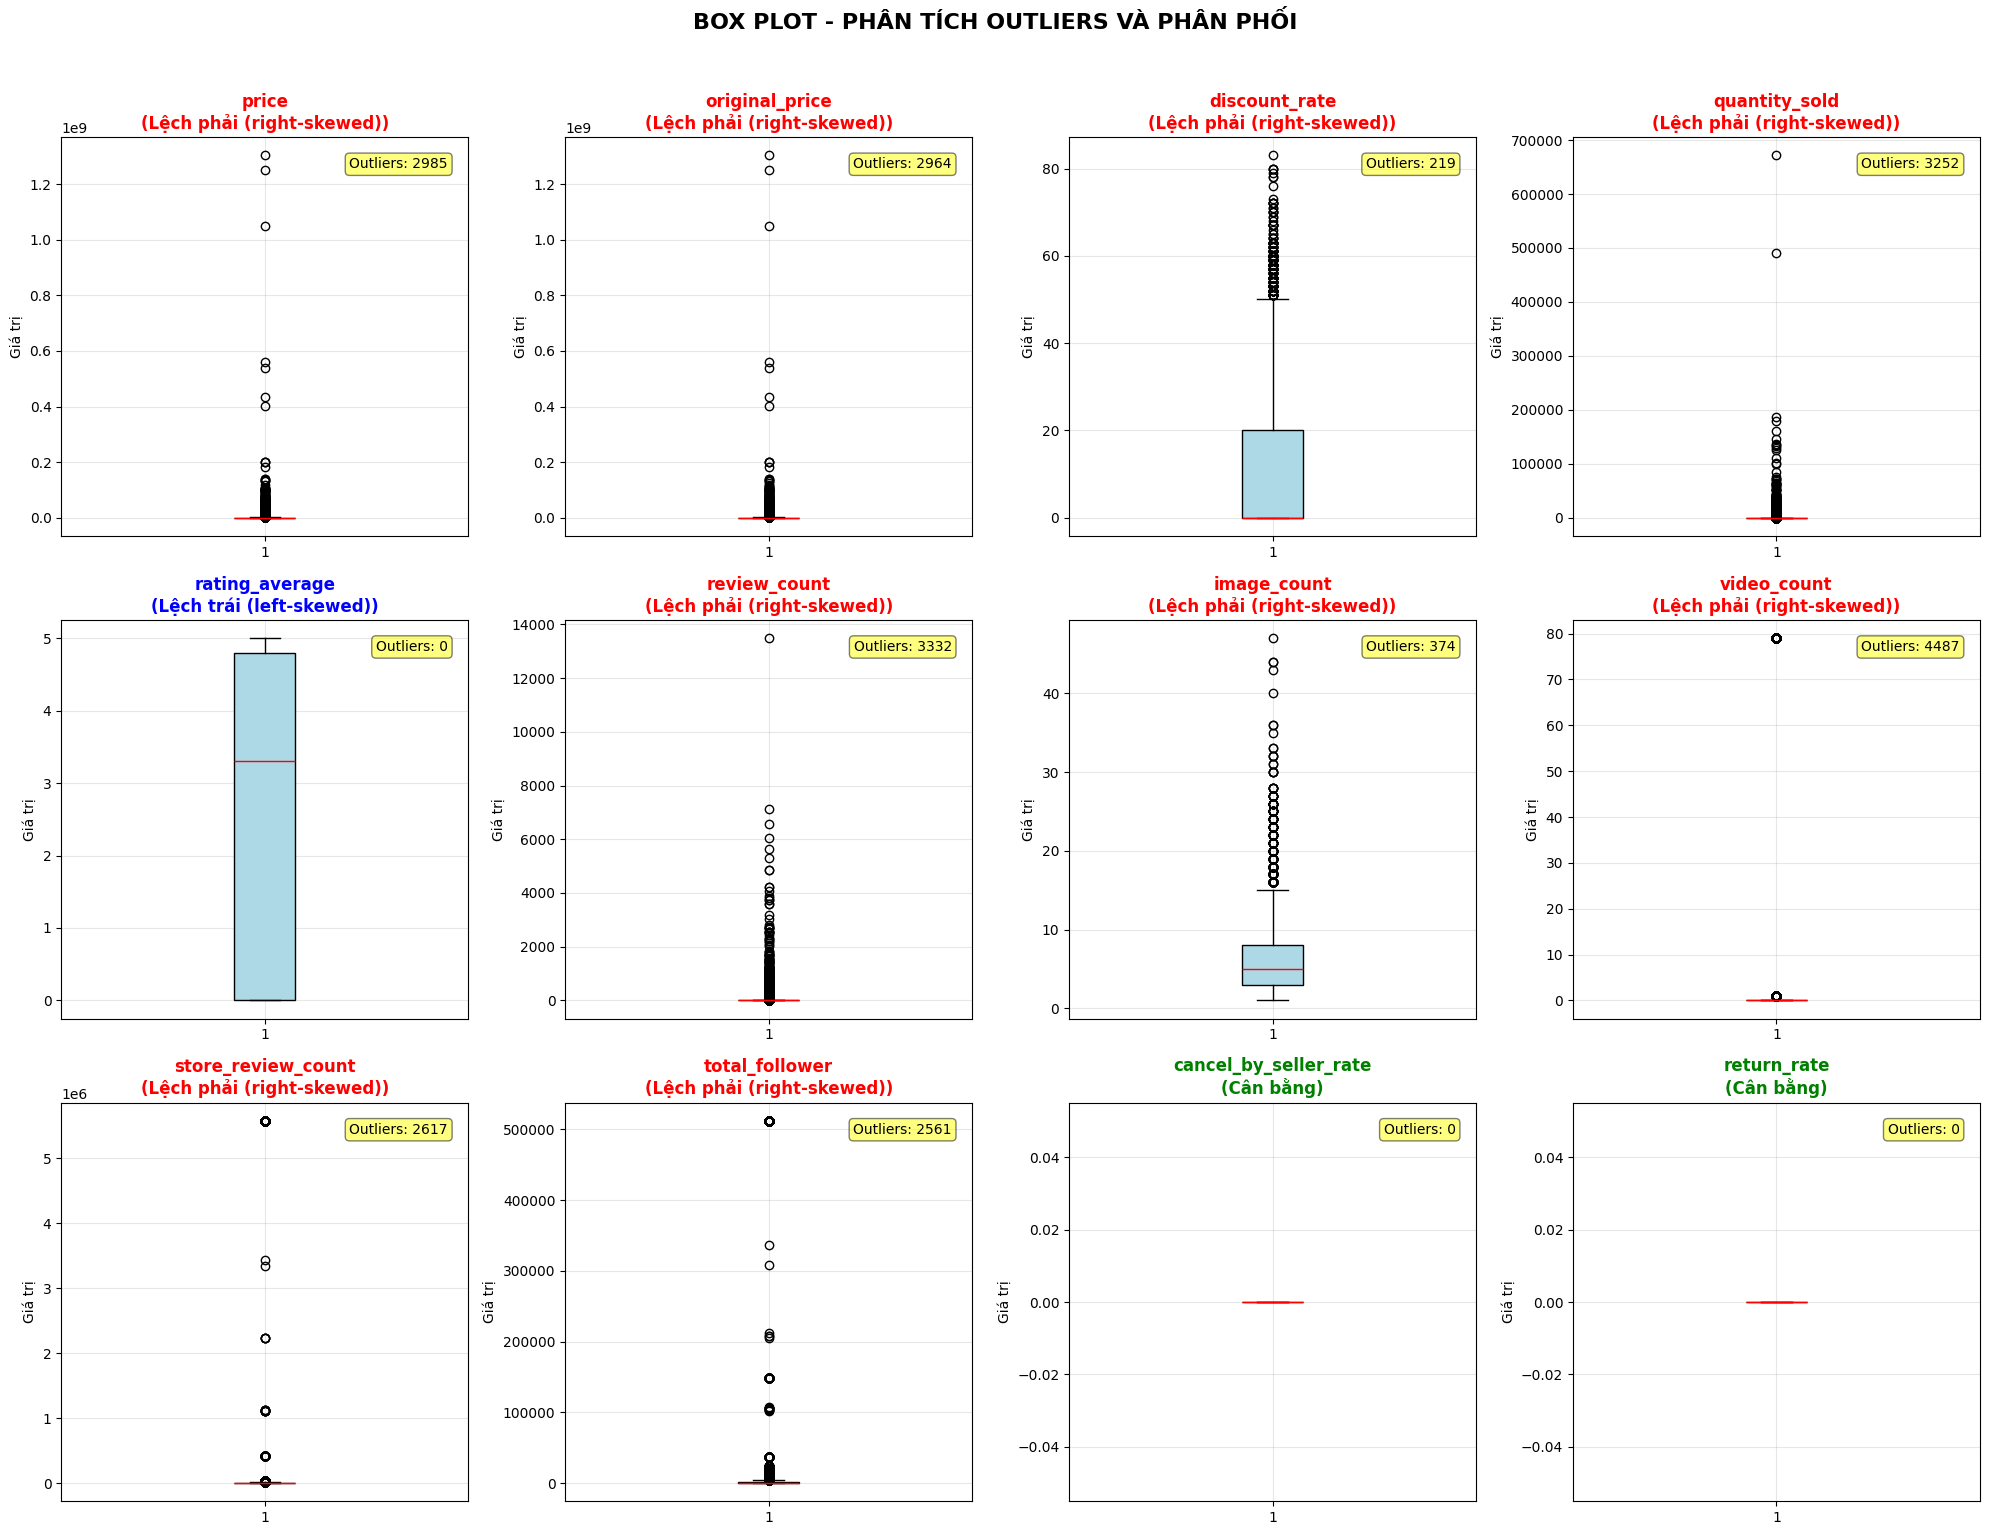


KẾT THÚC PHÂN TÍCH


In [17]:
#!pip install seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. ĐỌC DỮ LIỆU
df = pd.read_csv('data_imputed.csv')
print(f"Đã đọc dữ liệu: {df.shape[0]} dòng, {df.shape[1]} cột\n")

# 2. DANH SÁCH CÁC CỘT CẦN PHÂN TÍCH
columns_for_boxplot = [
    'price', 'original_price', 'discount_rate', 'quantity_sold',
    'rating_average', 'review_count', 'image_count', 'video_count',
    'store_review_count', 'total_follower', 
    'cancel_by_seller_rate', 'return_rate'
]

# 3. TÍNH TOÁN THÔNG SỐ OUTLIERS
print("="*80)
print("PHÂN TÍCH OUTLIERS THEO PHƯƠNG PHÁP IQR")
print("="*80)

results = []
for col in columns_for_boxplot:
    if col in df.columns:
        data = df[col]
        
        # Tính IQR và bounds
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Xác định outliers
        outliers = data[(data < lower_bound) | (data > upper_bound)]
        
        # Tính skewness (độ lệch)
        median = data.median()
        mean = data.mean()
        
        # Nhận xét về phân phối
        if median < mean:
            skewness_note = "Lệch phải (right-skewed)"
        elif median > mean:
            skewness_note = "Lệch trái (left-skewed)"
        else:
            skewness_note = "Cân bằng"
        
        # Lưu kết quả
        results.append({
            'Cột': col,
            'IQR': round(IQR, 2),
            'Lower Bound': round(lower_bound, 2),
            'Upper Bound': round(upper_bound, 2),
            'Số outliers': len(outliers),
            'Tỉ lệ outliers': f"{len(outliers)/len(data)*100:.1f}%",
            'Min outlier': round(outliers.min(), 2) if len(outliers) > 0 else "Không có",
            'Max outlier': round(outliers.max(), 2) if len(outliers) > 0 else "Không có",
            'Phân phối': skewness_note
        })

# 4. IN BẢNG KẾT QUẢ
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# 5. VẼ BOX PLOT
print("\n" + "="*80)
print("VẼ BOX PLOT")
print("="*80)

# Tạo figure lớn với nhiều subplot
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.flatten()

for i, col in enumerate(columns_for_boxplot):
    if i < len(axes):
        ax = axes[i]
        
        # Vẽ box plot
        boxplot = ax.boxplot(df[col].dropna(), patch_artist=True)
        
        # Tùy chỉnh màu sắc
        boxplot['boxes'][0].set_facecolor('lightblue')
        boxplot['medians'][0].set_color('red')
        
        # Thêm thông tin
        median_val = df[col].median()
        outliers_count = results[i]['Số outliers']
        
        # Đặt tiêu đề với thông tin phân phối
        color = 'red' if 'Lệch phải' in results[i]['Phân phối'] else 'blue' if 'Lệch trái' in results[i]['Phân phối'] else 'green'
        ax.set_title(f"{col}\n({results[i]['Phân phối']})", 
                    fontsize=12, fontweight='bold', color=color)
        ax.set_ylabel('Giá trị')
        ax.grid(True, alpha=0.3)
        
        # Hiển thị số outliers
        ax.text(0.95, 0.95, f'Outliers: {outliers_count}', 
                transform=ax.transAxes, fontsize=10,
                verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

# Ẩn các subplot không sử dụng
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('BOX PLOT - PHÂN TÍCH OUTLIERS VÀ PHÂN PHỐI', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\nKẾT THÚC PHÂN TÍCH")
print("="*80)

 Đã đọc file data_imputed.csv với 19811 dòng và 29 cột

 Đã lưu file tiền xử lý tại: data_preprocessing.csv

==================== THỐNG KÊ SAU TIỀN XỬ LÝ ====================
                  Cột      Min       Max      Mean    Median       Std   Variance       25%       75%
                price 9.546884 17.343018 12.594566 12.345839  1.596829   2.549862 11.532738 13.290418
       original_price 9.615872 17.370830 12.704445 12.464587  1.588631   2.523750 11.678448 13.399997
        discount_rate 0.000000 52.000000  9.004291  0.000000 13.816046 190.883121  0.000000 20.000000
        quantity_sold 0.000000  9.169977  2.317290  1.791759  2.299663   5.288452  0.000000  3.784190
       rating_average 0.000000  5.000000  2.410393  3.300000  2.358368   5.561902  0.000000  4.800000
         review_count 0.000000  6.268717  1.156014  0.693147  1.556666   2.423207  0.000000  1.791759
     is_return_policy 0.000000  1.000000  0.943769  1.000000  0.230374   0.053072  1.000000  1.000000
     is_f

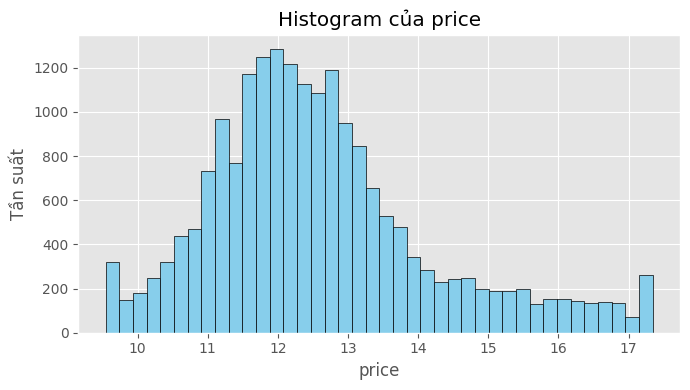

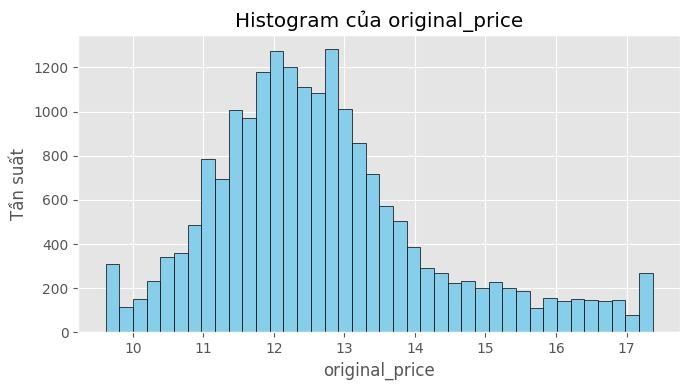

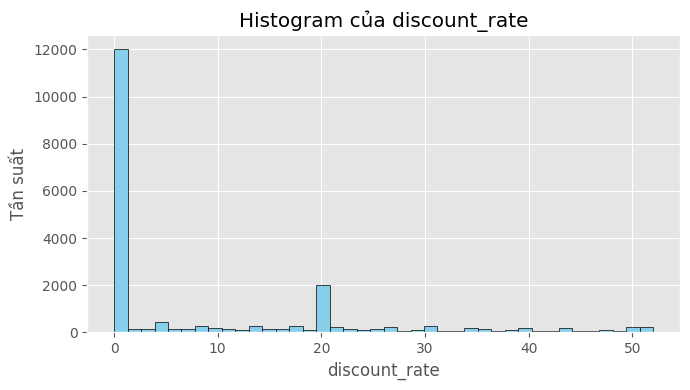

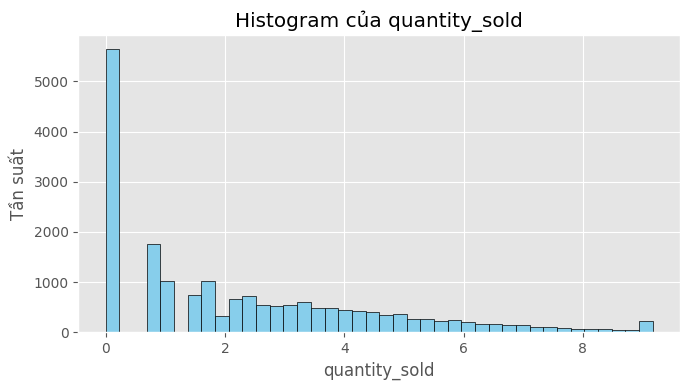

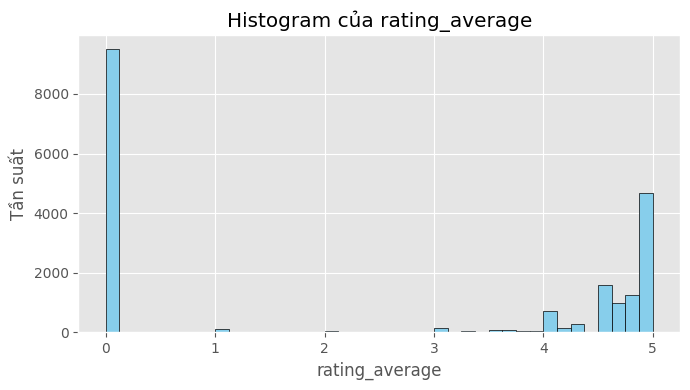

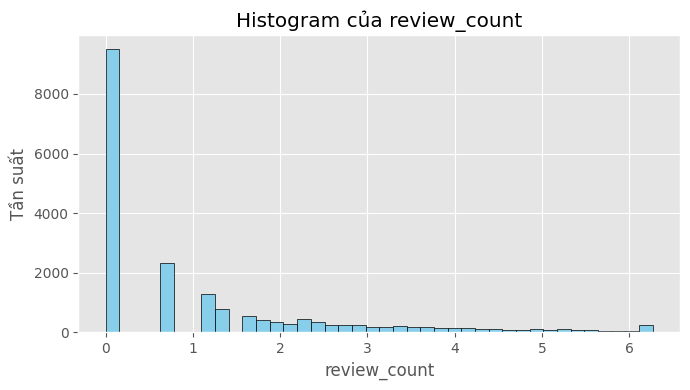

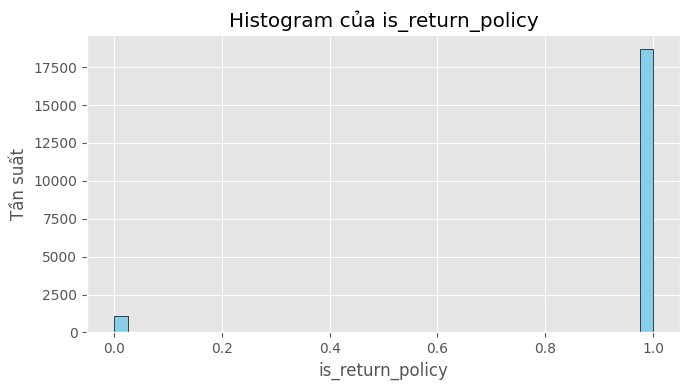

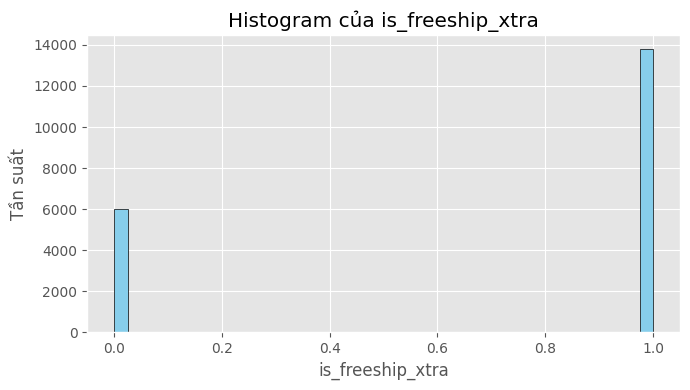

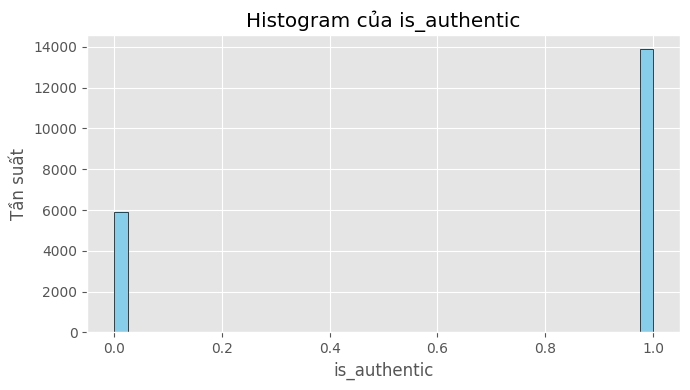

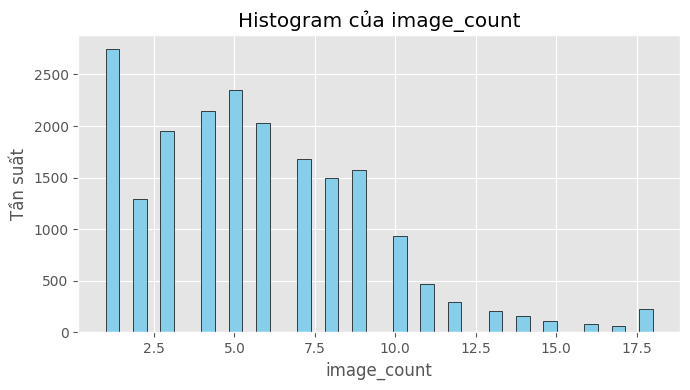

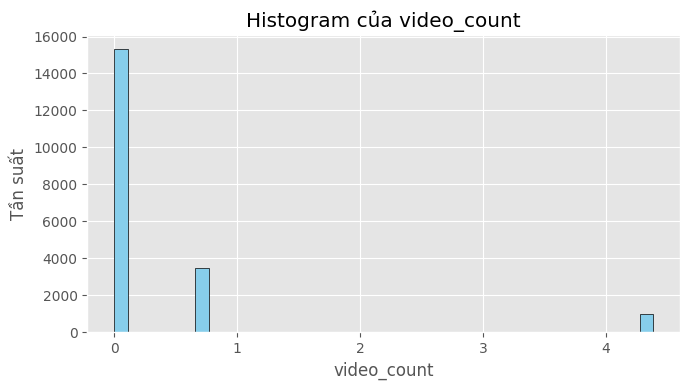

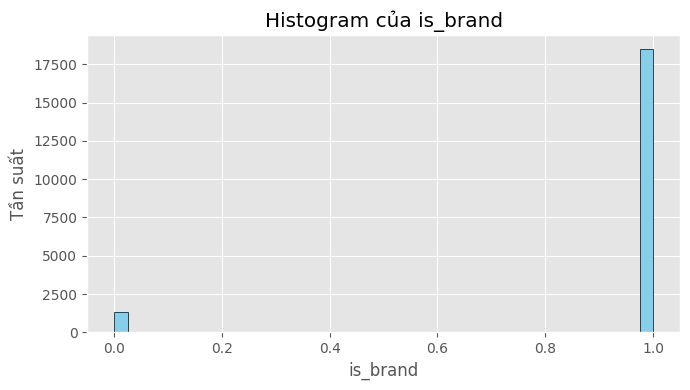

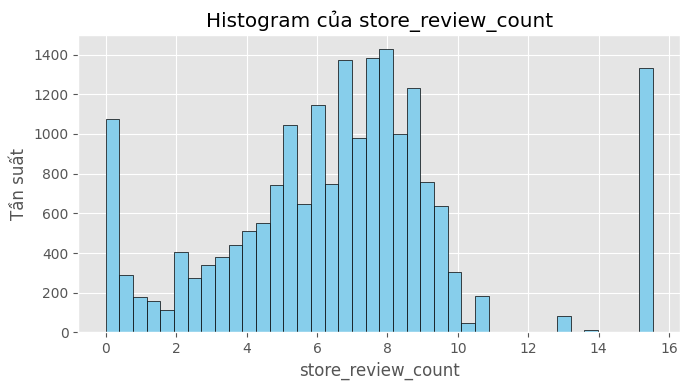

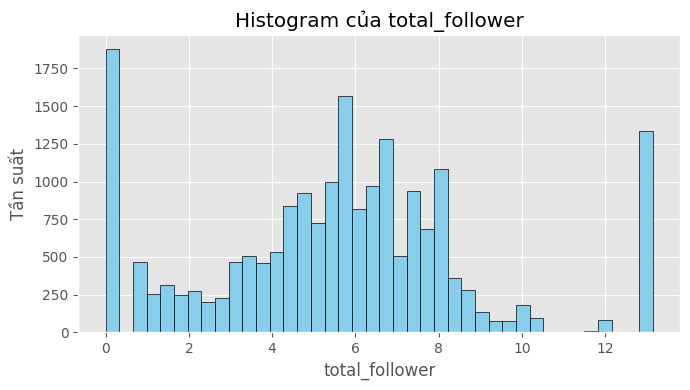

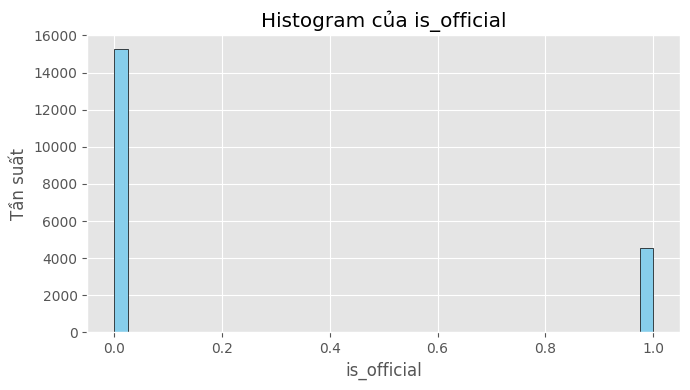

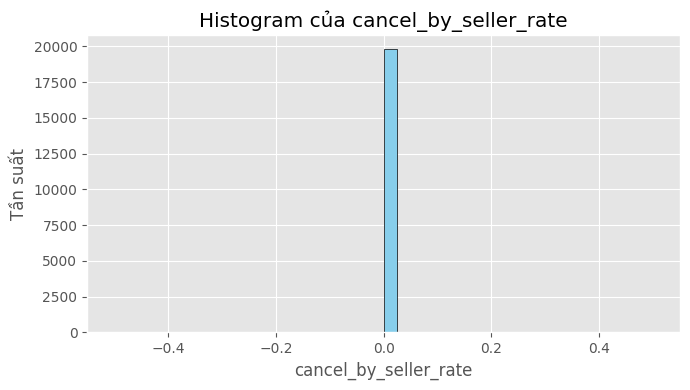

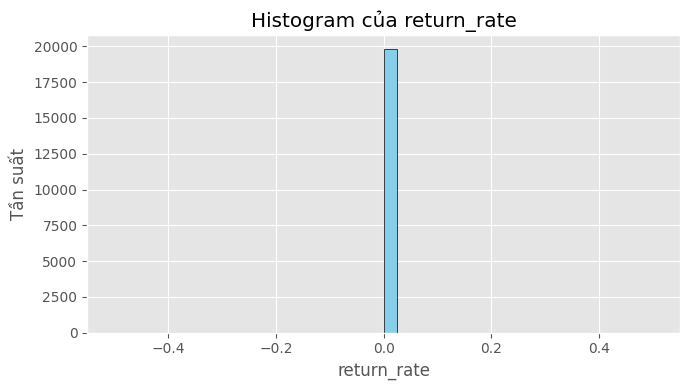

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

# ================== ĐỌC FILE INPUT ==================
input_file = "data_imputed.csv"

if not os.path.exists(input_file):
    raise FileNotFoundError(f" Không tìm thấy file {input_file}")

df = pd.read_csv(input_file)
print(f" Đã đọc file {input_file} với {len(df)} dòng và {len(df.columns)} cột")

# ================== HÀM WINSORIZING ==================
def winsorize_series(s, lower_q=0.01, upper_q=0.99):
    lower = s.quantile(lower_q)
    upper = s.quantile(upper_q)
    return s.clip(lower, upper)

# ================== CÁC CỘT CẦN XỬ LÝ ==================
winsor_log_cols = [
    "price", "original_price", "quantity_sold",
    "review_count", "video_count", "store_review_count",
    "total_follower"
]

winsor_only_cols = ["discount_rate", "image_count"]

df_pre = df.copy()

# ================== XỬ LÝ WINSOR + LOG  ==================
for col in winsor_log_cols:
    if col in df_pre.columns:
        numeric_col = pd.to_numeric(df_pre[col], errors="coerce")
        # Winsorize
        numeric_col = winsorize_series(numeric_col)
        # Clip lower = 0 để đảm bảo không âm khi lấy log
        numeric_col = numeric_col.clip(lower=0)
        # Áp dụng log1p và gán lại cột
        df_pre[col] = np.log1p(numeric_col)

# ================== WINSOR NHẸ ==================
for col in winsor_only_cols:
    if col in df_pre.columns:
        numeric_col = pd.to_numeric(df_pre[col], errors="coerce")
        df_pre[col] = winsorize_series(numeric_col)

# ================== LƯU FILE OUTPUT ==================
output_file = "data_preprocessing.csv"
df_pre.to_csv(output_file, index=False, encoding="utf-8")
print(f"\n Đã lưu file tiền xử lý tại: {output_file}")

# ================== THỐNG KÊ ==================
selected_cols = [
    'price', 'original_price', 'discount_rate', 'quantity_sold',
    'rating_average', 'review_count', 'is_return_policy',
    'is_freeship_xtra', 'is_authentic', 'image_count', 'video_count',
    'is_brand', 'store_review_count', 'total_follower', 'is_official',
    'cancel_by_seller_rate', 'return_rate'
]

selected_numeric_cols = [c for c in selected_cols if c in df_pre.columns]

stats = []

for col in selected_numeric_cols:
    s = pd.to_numeric(df_pre[col], errors="coerce").dropna()
    
    stats.append({
        "Cột": col,
        "Min": s.min(),
        "Max": s.max(),
        "Mean": s.mean(),
        "Median": s.median(),
        "Std": s.std(),
        "Variance": s.var(),
        "25%": s.quantile(0.25),
        "75%": s.quantile(0.75)
    })

stats_df = pd.DataFrame(stats)

print("\n==================== THỐNG KÊ SAU TIỀN XỬ LÝ ====================")
print(stats_df.to_string(index=False))

# ================== VẼ HISTOGRAM ==================
plt.style.use("ggplot")

for col in selected_numeric_cols:
    plt.figure(figsize=(7, 4))
    plt.hist(df_pre[col].dropna(), bins=40, color="skyblue", edgecolor="black")
    plt.title(f"Histogram của {col}")
    plt.xlabel(col)
    plt.ylabel("Tần suất")
    plt.tight_layout()
    plt.show()

